In [ ]:
# libraries
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras import initializers
from tensorflow.keras.optimizers import SGD, Adam

import numpy as np
import matplotlib.pyplot as plt

In [ ]:
tf.random.set_seed(42)
np.random.seed(42)

In [ ]:
# loading dataset
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
# normalizing pixels
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

In [ ]:
# flatning images into 784-d vectors
x_train = x_train.reshape(-1, 28 * 28)
x_test = x_test.reshape(-1, 28 * 28)

In [ ]:
# one hot encoding labels
y_train = keras.utils.to_categorical(y_train, num_classes=10)
y_test = keras.utils.to_categorical(y_test, num_classes=10)

In [ ]:
print(x_train.shape)
print(x_test.shape)

(60000, 784)
(10000, 784)


In [ ]:
# build_model function
def build_model(init_type):

  model = keras.Sequential()

  model.add(layers.Dense(512, activation="relu", kernel_initializer=init_type, input_shape = (784,)))

  model.add(layers.Dense(128, activation="relu", kernel_initializer=init_type))

  model.add(layers.Dense(64, activation="relu", kernel_initializer=init_type))

  model.add(layers.Dense(10, activation="softmax"))

  return model

### Random normal weight initialization

In [ ]:
model_random = build_model(initializers.RandomNormal())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model_random.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 512)            │       401,920 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        65,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,429,472 (5.45 MB)

 Trainable params: 476,490 (1.82 MB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 952,982 (3.64 MB)

In [ ]:
# compile model
model_random.compile(optimizer=Adam(learning_rate=0.001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# train model
history_random = model_random.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.2, verbose=1)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9126 - loss: 0.3042 - val_accuracy: 0.9563 - val_loss: 0.1453
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9682 - loss: 0.1058 - val_accuracy: 0.9669 - val_loss: 0.1091
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9801 - loss: 0.0669 - val_accuracy: 0.9714 - val_loss: 0.0972
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9864 - loss: 0.0445 - val_accuracy: 0.9685 - val_loss: 0.1124
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.9892 - loss: 0.0345 - val_accuracy: 0.9720 - val_loss: 0.1032
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9910 - loss: 0.0279 - val_accuracy: 0.9751 - val_loss: 0.1012
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9932 - loss: 0.0220 - val_accuracy: 0.9761 - val_loss: 0.0933
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9943 - loss: 0.0184 - val_accuracy: 0.

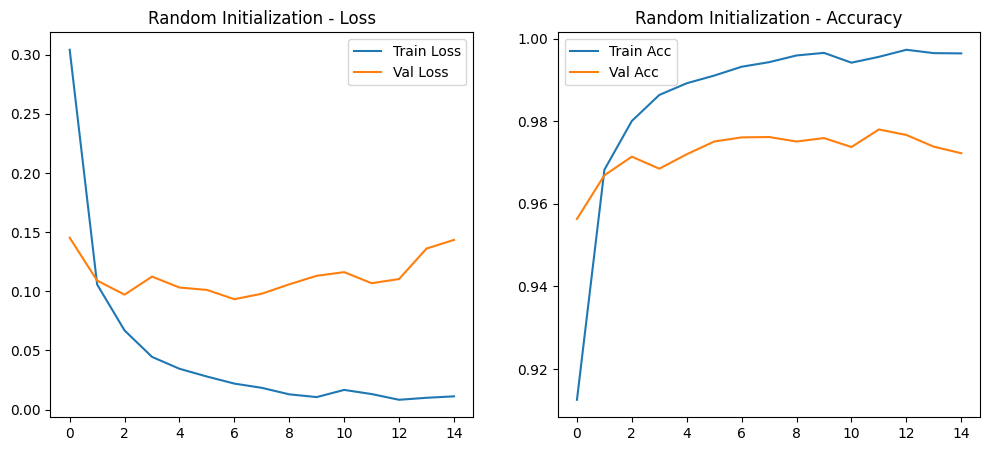

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

plot_history(history_random, "Random Initialization")
# plot_history(history_xavier, "Xavier Init")
# plot_history(history_he, "He Init")

Xavier_initialization

In [ ]:
# build_model function
def build_model_xavier(init_type):

  model = keras.Sequential()

  model.add(layers.Dense(512, activation="tanh", kernel_initializer=init_type, input_shape = (784,)))

  model.add(layers.Dense(256, activation="tanh", kernel_initializer=init_type))

  model.add(layers.Dense(128, activation="tanh", kernel_initializer=init_type))

  model.add(layers.Dense(64, activation="tanh", kernel_initializer=init_type))

  model.add(layers.Dense(10, activation="softmax"))

  return model

In [ ]:
model_xavier = build_model_xavier(initializers.GlorotUniform())

In [ ]:
# compile model
model_xavier.compile(optimizer=Adam(learning_rate=0.001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# train model
history_xavier = model_xavier.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.2, verbose=1)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - accuracy: 0.9156 - loss: 0.2909 - val_accuracy: 0.9433 - val_loss: 0.1795
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9603 - loss: 0.1340 - val_accuracy: 0.9631 - val_loss: 0.1242
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9727 - loss: 0.0904 - val_accuracy: 0.9689 - val_loss: 0.1044
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9811 - loss: 0.0641 - val_accuracy: 0.9682 - val_loss: 0.1075
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9856 - loss: 0.0471 - val_accuracy: 0.9671 - val_loss: 0.1165
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.9877 - loss: 0.0403 - val_accuracy: 0.9725 - val_loss: 0.1038
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9892 - loss: 0.0343 - val_accuracy: 0.9716 - val_loss: 0.1055
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9901 - loss: 0.0305 - val_accuracy: 0.

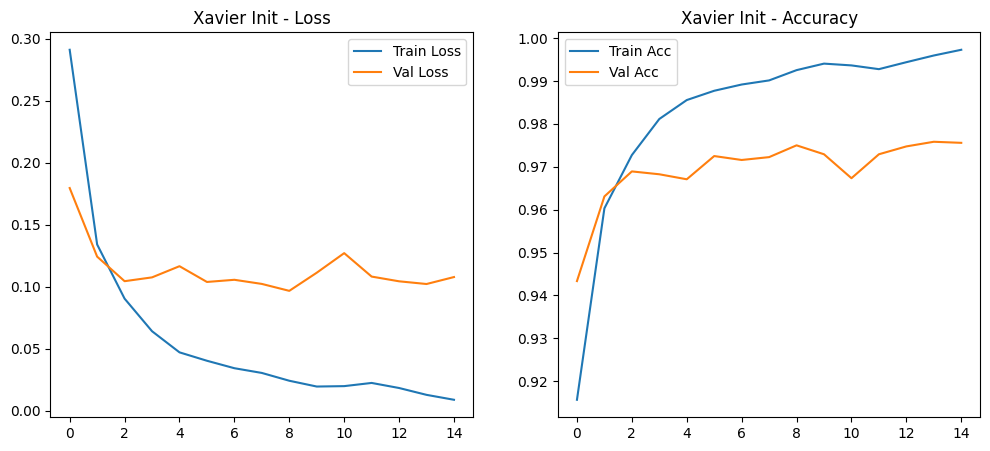

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

# plot_history(history_random, "Random Initialization")
plot_history(history_xavier, "Xavier Init")
# plot_history(history_he, "He Init")

He initialization with Adam optimizer

In [ ]:
model_he = build_model(initializers.HeNormal())

In [ ]:
# compile model
model_he.compile(optimizer=Adam(learning_rate=0.001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# train model
history_he = model_he.fit(x_train, y_train, epochs=15, batch_size=128, validation_split=0.2, verbose=1)


Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step - accuracy: 0.9187 - loss: 0.2753 - val_accuracy: 0.9574 - val_loss: 0.1419
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9705 - loss: 0.0984 - val_accuracy: 0.9662 - val_loss: 0.1097
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9824 - loss: 0.0602 - val_accuracy: 0.9701 - val_loss: 0.1036
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9877 - loss: 0.0418 - val_accuracy: 0.9726 - val_loss: 0.0950
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9910 - loss: 0.0301 - val_accuracy: 0.9747 - val_loss: 0.1017
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.9923 - loss: 0.0247 - val_accuracy: 0.9748 - val_loss: 0.0977
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 2s 5ms/step - accuracy: 0.9935 - loss: 0.0196 - val_accuracy: 0.9768 - val_loss: 0.0994
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9945 - loss: 0.0168 - val_accuracy: 0.

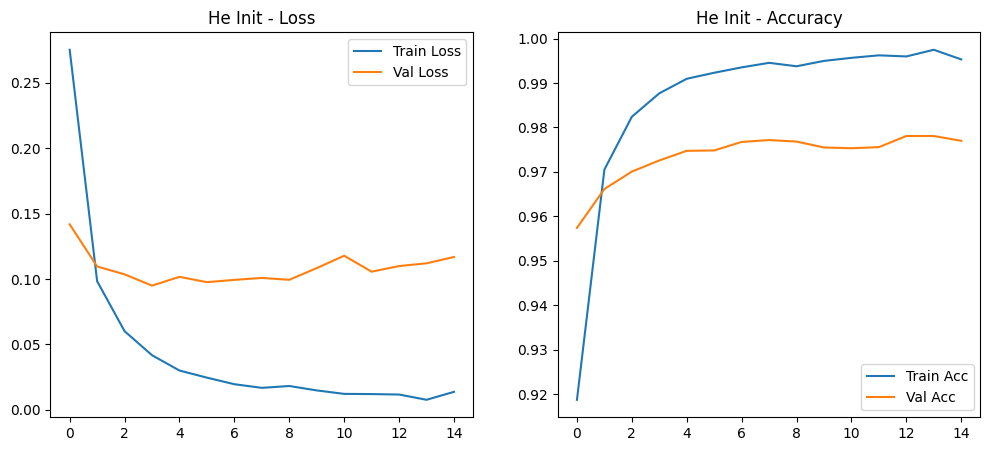

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()

# plot_history(history_random, "Random Initialization")
# plot_history(history_xavier, "Xavier Init")
plot_history(history_he, "He Init")

He initialization and SGD optimizer

In [ ]:
model_he_sgd = build_model(initializers.HeNormal())

In [ ]:
model_he_sgd.compile(optimizer=SGD(learning_rate=0.001), loss = 'categorical_crossentropy', metrics=['accuracy'])

In [ ]:
# training model
history_he_sgd = model_he_sgd.fit(x_train, y_train, epochs= 15, batch_size = 128, validation_split=0.2, verbose=1)

Epoch 1/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - accuracy: 0.2077 - loss: 2.2096 - val_accuracy: 0.3820 - val_loss: 2.0243
Epoch 2/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.5107 - loss: 1.8700 - val_accuracy: 0.6383 - val_loss: 1.6866
Epoch 3/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.6841 - loss: 1.5387 - val_accuracy: 0.7484 - val_loss: 1.3524
Epoch 4/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7582 - loss: 1.2272 - val_accuracy: 0.7985 - val_loss: 1.0605
Epoch 5/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.7945 - loss: 0.9801 - val_accuracy: 0.8257 - val_loss: 0.8515
Epoch 6/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8179 - loss: 0.8116 - val_accuracy: 0.8443 - val_loss: 0.7129
Epoch 7/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8346 - loss: 0.6986 - val_accuracy: 0.8587 - val_loss: 0.6191
Epoch 8/15
375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8478 - loss: 0.6203 - val_accuracy: 0.

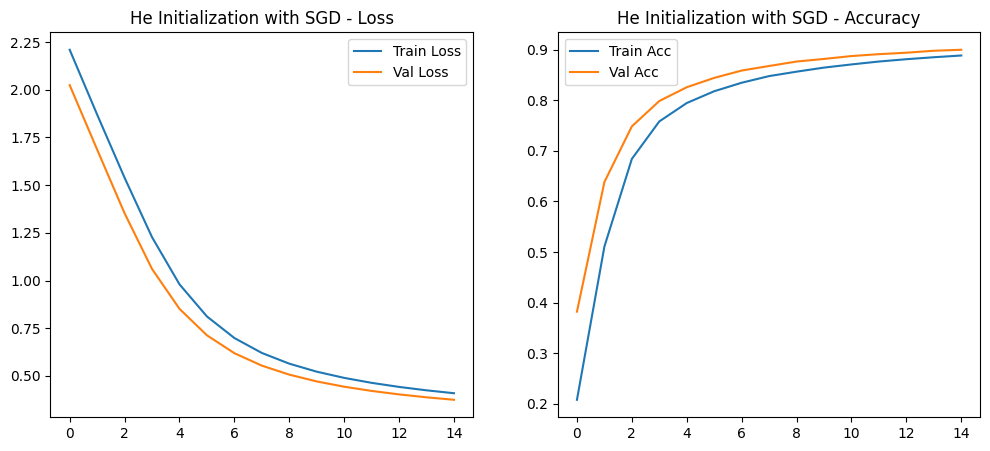

In [ ]:
def plot_history(history, title):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(title + " - Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(title + " - Accuracy")
    plt.legend()

    plt.show()


plot_history(history_he_sgd, "He Initialization with SGD")

Comparing Final Accuracy

In [ ]:
# comparing final accuracy

print("Random Initialization Accuracy:", history_random.history['val_accuracy'][-1])
print("Xavier Initialization Accuracy:", history_xavier.history['val_accuracy'][-1])
print("He Initialization Accuracy:", history_he.history['val_accuracy'][-1])
print("He Initialization with SGD Accuracy:", history_he_sgd.history['val_accuracy'][-1])


Random Initialization Accuracy: 0.9722499847412109
Xavier Initialization Accuracy: 0.9755833148956299
He Initialization Accuracy: 0.9769999980926514
He Initialization with SGD Accuracy: 0.8998333215713501
